In [100]:
"""
PROJECT: Coal Demand Forecasting & Procurement Optimization

BUSINESS PROBLEM
----------------
Coal-based power plants are experiencing significant inventory volatility
(40–60%) due to reactive procurement strategies and poor alignment between
generation planning and coal ordering.

KEY CHALLENGES
--------------
1. Inventory Volatility
   - Coal inventory fluctuates heavily because procurement decisions are reactive
   rather than forecast-driven.

2. Operational Lag
   - There is a 2–3 week delay between generation planning and coal ordering,
   which increases the risk of supply-demand mismatch.

3. Seasonality in Demand
   - Electricity demand peaks during summer months and can increase coal demand
   by approximately 35%.
   - Current procurement processes do not anticipate these peaks effectively.

PROJECT OBJECTIVE
-----------------
Develop a data-driven forecasting and procurement optimization framework
to improve coal inventory management.

PROJECT SCOPE
-------------
1. Forecast coal demand for a horizon of 30–90 days.
2. Identify demand patterns across:
      - States
      - Coal consuming sectors
      - Time trends
3. Develop predictive models to forecast coal consumption.
4. Enable proactive procurement planning to reduce cost and supply risk.

EXPECTED DELIVERABLES
---------------------
1. Cleaned and structured dataset for modeling.
2. Forecasting model for coal demand.
3. Scenario analysis for peak demand situations.
4. Inventory policy recommendations.
5. Data outputs that can integrate with ERP / operational dashboards.
"""

# -----------------------------------------------------------
# STEP 1: Import Required Libraries
# -----------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------------------------------
# STEP 2: Load Dataset
# -----------------------------------------------------------

data = pd.read_csv("coal.csv")

# -----------------------------------------------------------
# STEP 3: Inspect Dataset
# -----------------------------------------------------------

print("Dataset Shape:", data.shape)
print("\nColumn Names:\n", data.columns)

print("\nFirst 5 Rows:")
print(data.head())

print("\nData Info:")
print(data.info())

print("\nSummary Statistics:")
print(data.describe())

# -----------------------------------------------------------
# STEP 4: Check Missing Values
# -----------------------------------------------------------

print("\nMissing Values:")
print(data.isnull().sum())

# -----------------------------------------------------------
# STEP 5: Initial Business Question Checks
# -----------------------------------------------------------

# Total coal consumption by year
coal_by_year = data.groupby("Year")["Coal Consumed"].sum()

print("\nTotal Coal Consumption by Year:")
print(coal_by_year)

# Total coal consumption by sector
coal_by_sector = data.groupby("Coal Consuming Sectors")["Coal Consumed"].sum()

print("\nCoal Consumption by Sector:")
print(coal_by_sector)

# Top states consuming coal
coal_by_state = data.groupby("srcStateName")["Coal Consumed"].sum().sort_values(ascending=False)

print("\nTop Coal Consuming States:")
print(coal_by_state.head(10))

Dataset Shape: (1957, 7)

Column Names:
 Index(['srcStateName', 'srcYear', 'Types of coal', 'Coal Consuming Sectors',
       'Coal Consumed', 'YearCode', 'Year'],
      dtype='object')

First 5 Rows:
     srcStateName  srcYear Types of coal Coal Consuming Sectors  \
0           DELHI     2011      RAW COAL                  OTHER   
1          PUNJAB     2011      RAW COAL        POWER (UTILITY)   
2  ANDHRA PRADESH     2011      RAW COAL        POWER (CAPTIVE)   
3           ASSAM     2011      RAW COAL           PULP & PAPER   
4          PUNJAB     2011      RAW COAL            FERTILISERS   

   Coal Consumed  YearCode                              Year  
0          0.131      2011  Financial Year (Apr - Mar), 2011  
1         12.545      2011  Financial Year (Apr - Mar), 2011  
2          3.363      2011  Financial Year (Apr - Mar), 2011  
3          0.095      2011  Financial Year (Apr - Mar), 2011  
4          1.111      2011  Financial Year (Apr - Mar), 2011  

Data Info:
<class 

In [101]:
# -----------------------------------------------------------
# DATA COLLECTION
# -----------------------------------------------------------

"""
DATA SOURCE
-----------
Dataset: coal.csv

Source Type:
Historical coal consumption data categorized by:
- State
- Year
- Coal type
- Coal consuming sector

Purpose:
To analyze historical coal consumption patterns and build
forecasting models to optimize procurement and inventory planning.
"""

import pandas as pd

# Load dataset
file_path = "coal.csv"
df = pd.read_csv(file_path)

print("Dataset Loaded Successfully")
print("Shape of Dataset:", df.shape)

Dataset Loaded Successfully
Shape of Dataset: (1957, 7)


In [102]:
# -----------------------------------------------------------
# DATA VERSION CONTROL
# -----------------------------------------------------------

"""
DATA VERSION INFORMATION
------------------------
Version: v1.0
Dataset Name: coal.csv
Last Updated: 2026
Storage Location: Local project directory

Version Control Strategy:
- Maintain dataset versions (v1, v2, v3)
- Track data cleaning steps
- Store processed datasets separately
- Maintain metadata documentation

Example naming convention:
coal_raw_v1.csv
coal_cleaned_v1.csv
coal_model_ready_v1.csv
"""

import datetime

data_version = "v1.0"
timestamp = datetime.datetime.now()

print("Data Version:", data_version)
print("Loaded on:", timestamp)

Data Version: v1.0
Loaded on: 2026-03-04 13:31:54.152766


| Supplier     | Input           | Process             | Output                     | Customer         |
| ------------ | --------------- | ------------------- | -------------------------- | ---------------- |
| ERP system   | Generation plan | Demand forecasting  | Coal demand forecast       | Procurement team |
| SCADA system | Power output    | Feature engineering | Inventory alerts           | Operations       |
| Weather API  | Temperature     | Model training      | Procurement recommendation | Energy planners  |
| Market data  | Coal price      | Model deployment    | Risk monitoring            | Finance          |


Raw Data → DVC
Processed Data → DVC
Features → DVC

In [103]:
# Install DVC if not already installed
!pip install dvc

# Remove any existing Git and DVC setups for a clean start
!rm -rf .git
!rm -rf .dvc

# Initialize a Git repository
!git init

# Initialize DVC
!dvc init

# Add coal.csv to DVC
!dvc add coal.csv

# Add DVC-generated .dvc file to Git
!git add coal.csv.dvc

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/.git/
Initialized DVC repository.

You can now commit the changes to git.

+---------------------------------------------------------------------+
|                                                                     |
|        DVC has enabled anonymous aggregate usage analytics.         |
|     Read the analytics documentation (and how to opt-out) here:     |
|             <https://dvc.org/doc/user-guide/analytics>              |
|                                  

In [104]:
# -----------------------------------------------------------
# DATA QUALITY VERIFICATION
# -----------------------------------------------------------

"""
Objective:
Check dataset integrity and identify potential data issues.

Quality checks include:
1. Missing values
2. Duplicate records
3. Incorrect data types
4. Outliers
"""

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check duplicates
print("\nDuplicate Rows:", df.duplicated().sum())

# Data types
print("\nData Types:")
print(df.dtypes)


Missing Values:
srcStateName              0
srcYear                   0
Types of coal             0
Coal Consuming Sectors    0
Coal Consumed             0
YearCode                  0
Year                      0
dtype: int64

Duplicate Rows: 0

Data Types:
srcStateName               object
srcYear                     int64
Types of coal              object
Coal Consuming Sectors     object
Coal Consumed             float64
YearCode                    int64
Year                       object
dtype: object


In [105]:
# -----------------------------------------------------------
# DATA DESCRIPTION
# -----------------------------------------------------------

"""
Dataset Overview
----------------
The dataset contains historical coal consumption information.

Columns Description:

1. srcStateName
   State where coal is consumed.

2. srcYear
   Year of consumption record.

3. Types of coal
   Category of coal used.

4. Coal Consuming Sectors
   Sector where coal is consumed (power, industry, etc.)

5. Coal Consumed
   Quantity of coal consumed.

6. YearCode
   Encoded representation of year.

7. Year
   Year of record in numeric format.
"""

print("\nDataset Columns:")
print(df.columns)

print("\nSample Data:")
print(df.head())


Dataset Columns:
Index(['srcStateName', 'srcYear', 'Types of coal', 'Coal Consuming Sectors',
       'Coal Consumed', 'YearCode', 'Year'],
      dtype='object')

Sample Data:
     srcStateName  srcYear Types of coal Coal Consuming Sectors  \
0           DELHI     2011      RAW COAL                  OTHER   
1          PUNJAB     2011      RAW COAL        POWER (UTILITY)   
2  ANDHRA PRADESH     2011      RAW COAL        POWER (CAPTIVE)   
3           ASSAM     2011      RAW COAL           PULP & PAPER   
4          PUNJAB     2011      RAW COAL            FERTILISERS   

   Coal Consumed  YearCode                              Year  
0          0.131      2011  Financial Year (Apr - Mar), 2011  
1         12.545      2011  Financial Year (Apr - Mar), 2011  
2          3.363      2011  Financial Year (Apr - Mar), 2011  
3          0.095      2011  Financial Year (Apr - Mar), 2011  
4          1.111      2011  Financial Year (Apr - Mar), 2011  


In [106]:
# -----------------------------------------------------------
# DATA REQUIREMENTS
# -----------------------------------------------------------

"""
To build forecasting models the dataset must satisfy:

Mandatory Fields
----------------
1. Time Variable
   Year or date column for time series forecasting.

2. Target Variable
   Coal Consumed (Demand variable).

3. Dimensional Variables
   - State
   - Sector
   - Coal Type

Minimum Data Requirements
-------------------------
- No missing values in target variable
- Consistent year format
- Numeric format for coal consumption
"""

required_columns = [
    "srcStateName",
    "Types of coal",
    "Coal Consuming Sectors",
    "Coal Consumed",
    "Year"
]

print("Checking required columns...")

for col in required_columns:
    if col in df.columns:
        print(col, "✔ Present")
    else:
        print(col, "✘ Missing")

Checking required columns...
srcStateName ✔ Present
Types of coal ✔ Present
Coal Consuming Sectors ✔ Present
Coal Consumed ✔ Present
Year ✔ Present


In [107]:
# -----------------------------------------------------------
# DATA VERIFICATION
# -----------------------------------------------------------

"""
Verification ensures the dataset is ready for analysis.

Checks include:
1. Value ranges
2. Aggregated totals
3. Logical consistency
"""

# Verify coal consumption values
print("\nCoal Consumption Statistics:")
print(df["Coal Consumed"].describe())

# Verify yearly aggregation
yearly_consumption = df.groupby("Year")["Coal Consumed"].sum()

print("\nTotal Coal Consumption by Year:")
print(yearly_consumption)

# Verify sector level aggregation
sector_consumption = df.groupby("Coal Consuming Sectors")["Coal Consumed"].sum()

print("\nCoal Consumption by Sector:")
print(sector_consumption)


Coal Consumption Statistics:
count    1957.000000
mean        3.387410
std         9.495445
min         0.000000
25%         0.035000
50%         0.214000
75%         1.340000
max        79.342000
Name: Coal Consumed, dtype: float64

Total Coal Consumption by Year:
Year
Financial Year (Apr - Mar), 2011    555.524
Financial Year (Apr - Mar), 2012    573.229
Financial Year (Apr - Mar), 2013    611.644
Financial Year (Apr - Mar), 2014    611.423
Financial Year (Apr - Mar), 2015    647.511
Financial Year (Apr - Mar), 2016    672.429
Financial Year (Apr - Mar), 2017    687.679
Financial Year (Apr - Mar), 2018    733.632
Financial Year (Apr - Mar), 2019    781.906
Financial Year (Apr - Mar), 2020    754.185
Name: Coal Consumed, dtype: float64

Coal Consumption by Sector:
Coal Consuming Sectors
BRICKS                                 13.436
CEMENT                                108.505
CHEMICAL                                7.740
COKERIES                                3.149
COLLIERY OWN - C

In [108]:
# -----------------------------------------------------------
# DATA PREPARATION
# -----------------------------------------------------------

"""
Objective:
Prepare the dataset for forecasting and analytical modeling
by selecting relevant data, cleaning inconsistencies,
engineering useful features, and standardizing formats.
"""

import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("coal.csv")

print("Initial Dataset Shape:", df.shape)

Initial Dataset Shape: (1957, 7)


In [109]:
# -----------------------------------------------------------
# FEATURE SELECTION
# -----------------------------------------------------------

"""
Selecting relevant features required for forecasting
coal demand and analyzing consumption patterns.
"""

selected_features = [
    'srcStateName',
    'Types of coal',
    'Coal Consuming Sectors',
    'Coal Consumed',
    'Year'
]

df_selected = df[selected_features]

print("Selected Columns:")
print(df_selected.columns)

Selected Columns:
Index(['srcStateName', 'Types of coal', 'Coal Consuming Sectors',
       'Coal Consumed', 'Year'],
      dtype='object')


In [110]:
# -----------------------------------------------------------
# DATA SELECTION
# -----------------------------------------------------------

"""
Filtering dataset to keep only relevant records.
Example: selecting power generation sector
which is typically the largest coal consumer.
"""

df_power = df_selected[df_selected['Coal Consuming Sectors'].notna()]

print("Filtered Dataset Shape:", df_power.shape)

Filtered Dataset Shape: (1957, 5)


In [111]:
# -----------------------------------------------------------
# UNBALANCED CLASSES CHECK
# -----------------------------------------------------------

"""
Check if certain sectors or states dominate
the dataset distribution.
"""

sector_distribution = df_power['Coal Consuming Sectors'].value_counts()

print("Sector Distribution:")
print(sector_distribution)

Sector Distribution:
Coal Consuming Sectors
POWER (UTILITY)                      305
OTHER                                285
POWER (CAPTIVE)                      255
CEMENT                               216
PULP & PAPER                         145
SPONGE IRON                          119
CHEMICAL                             108
TEXTILES & RAYONS                     98
METALLURGICAL USE- COKERIES           84
FERTILISERS                           75
BRICKS                                67
METALLURGICAL USE- DIRECT FEED        63
STEEL (BOILERS)                       47
COLLIERY OWN - CONSUMPTION            44
OTHER BASIC-METAL (ALUMINIUM ETC)     40
COKERIES                               5
COLLIERY STAFF                         1
Name: count, dtype: int64


In [112]:
# -----------------------------------------------------------
# NOISE REDUCTION
# -----------------------------------------------------------

"""
Remove inconsistent or invalid records
such as negative coal consumption values.
"""

df_power = df_power[df_power['Coal Consumed'] >= 0]

print("Dataset after removing noisy records:", df_power.shape)

Dataset after removing noisy records: (1957, 5)


In [113]:
# -----------------------------------------------------------
# DATA IMPUTATION
# -----------------------------------------------------------

"""
Handle missing values in the dataset.
"""

# Check missing values
print("Missing Values:")
print(df_power.isnull().sum())

# Impute missing numeric values with median
df_power['Coal Consumed'] = df_power['Coal Consumed'].fillna(
    df_power['Coal Consumed'].median()
)

# Impute categorical values with mode
df_power['Types of coal'] = df_power['Types of coal'].fillna(
    df_power['Types of coal'].mode()[0]
)

Missing Values:
srcStateName              0
Types of coal             0
Coal Consuming Sectors    0
Coal Consumed             0
Year                      0
dtype: int64


In [114]:
df_power['Year_numeric'] = df_power['Year'].str.extract(r'(\d{4})$').astype(int)

# Example: Year trend index
df_power['Year_Index'] = df_power['Year_numeric'] - df_power['Year_numeric'].min()

# Aggregate demand per state per year
state_year_demand = df_power.groupby(
    ['srcStateName', 'Year_numeric']
)['Coal Consumed'].sum().reset_index()

print(state_year_demand.head())

     srcStateName  Year_numeric  Coal Consumed
0  ANDHRA PRADESH          2011         51.236
1  ANDHRA PRADESH          2012         56.543
2  ANDHRA PRADESH          2013         60.471
3  ANDHRA PRADESH          2014         57.210
4  ANDHRA PRADESH          2015         26.244


In [115]:
# -----------------------------------------------------------
# DATA AUGMENTATION
# -----------------------------------------------------------

"""
Creating additional derived metrics
for better modeling insights.
"""

# Rolling demand trend
state_year_demand['Demand_MA_3'] = (
    state_year_demand.groupby('srcStateName')['Coal Consumed']
    .rolling(3)
    .mean()
    .reset_index(level=0, drop=True)
)

In [116]:
# -----------------------------------------------------------
# FILE FORMAT STANDARDIZATION
# -----------------------------------------------------------

"""
Save cleaned dataset for further modeling.
"""

state_year_demand.to_csv("coal_cleaned_dataset.csv", index=False)

print("Cleaned dataset saved successfully")

Cleaned dataset saved successfully


In [117]:
# -----------------------------------------------------------
# NORMALIZATION
# -----------------------------------------------------------

"""
Normalize numerical features to improve
machine learning model performance.
"""

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

state_year_demand['Coal_Consumed_Normalized'] = scaler.fit_transform(
    state_year_demand[['Coal Consumed']]
)

print(state_year_demand.head())

     srcStateName  Year_numeric  Coal Consumed  Demand_MA_3  \
0  ANDHRA PRADESH          2011         51.236          NaN   
1  ANDHRA PRADESH          2012         56.543          NaN   
2  ANDHRA PRADESH          2013         60.471    56.083333   
3  ANDHRA PRADESH          2014         57.210    58.074667   
4  ANDHRA PRADESH          2015         26.244    47.975000   

   Coal_Consumed_Normalized  
0                  0.548936  
1                  0.605794  
2                  0.647878  
3                  0.612940  
4                  0.281175  


2015–2020 → steady growth
2020 → decline due to demand shock
2021 onwards → recovery trend

Power sector consumes >70% of coal
Industry second largest consumer

In [118]:
# -----------------------------------------------------------
# LITERATURE RESEARCH REFERENCES
# -----------------------------------------------------------

"""
Relevant research areas:

1. Energy demand forecasting using ARIMA and SARIMA
2. Deep learning models for power load forecasting (LSTM, GRU)
3. Hybrid models combining statistical and ML methods
4. Weather-driven electricity demand prediction
5. Coal supply chain optimization models

These insights guide model selection and feature design.
"""

'\nRelevant research areas:\n\n1. Energy demand forecasting using ARIMA and SARIMA\n2. Deep learning models for power load forecasting (LSTM, GRU)\n3. Hybrid models combining statistical and ML methods\n4. Weather-driven electricity demand prediction\n5. Coal supply chain optimization models\n\nThese insights guide model selection and feature design.\n'

Data Pipeline
      │
      │
Feature Store
      │
      │
Model Training Environment
(Notebook / ML Pipeline)
      │
      │
Model Registry (MLflow)
      │
      │
Production API
(FastAPI)

In [119]:
# -----------------------------------------------------------
# PERFORMANCE METRICS
# -----------------------------------------------------------

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

def evaluate_model(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return {"MAE": mae, "RMSE": rmse, "R2": r2}

In [120]:
# -----------------------------------------------------------
# ROBUSTNESS TESTING
# -----------------------------------------------------------

def robustness_test(model, X_test, y_test):

    predictions = model.predict(X_test)

    metrics = evaluate_model(y_test, predictions)

    print("Robustness evaluation:")
    print(metrics)

In [121]:
# -----------------------------------------------------------
# LIBRARIES
# -----------------------------------------------------------

import pandas as pd
import numpy as np

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

import warnings
warnings.filterwarnings("ignore")

In [122]:
# -----------------------------------------------------------
# LOAD DATA
# -----------------------------------------------------------

df = pd.read_csv("coal_cleaned_dataset.csv")

# Rename columns to match the expected 'date' and 'coal_consumption'
df = df.rename(columns={'Year_numeric': 'date', 'Coal Consumed': 'coal_consumption'})

df['date'] = pd.to_datetime(df['date'], format='%Y')
df = df.sort_values('date')

y = df['coal_consumption']

In [123]:
# -----------------------------------------------------------
# SCALABILITY TEST
# -----------------------------------------------------------

import time

def scalability_test(model, X_sample):

    start = time.time()
    model.predict(X_sample)
    end = time.time()

    print("Prediction time:", end-start)

In [124]:
# -----------------------------------------------------------
# EXPLAINABILITY USING SHAP
# -----------------------------------------------------------

import shap

def explain_model(model, X_train):

    explainer = shap.Explainer(model)
    shap_values = explainer(X_train)

    shap.summary_plot(shap_values, X_train)

In [125]:
# -----------------------------------------------------------
# TRAIN TEST SPLIT
# -----------------------------------------------------------

split = int(len(df)*0.8)

train = df.iloc[:split]
test = df.iloc[split:]

y_train = train['coal_consumption']
y_test = test['coal_consumption']

In [126]:
# -----------------------------------------------------------
# BASELINE MODEL
# -----------------------------------------------------------

baseline_pred = y_test.shift(1)

baseline_mae = mean_absolute_error(y_test[1:], baseline_pred[1:])
baseline_rmse = np.sqrt(mean_squared_error(y_test[1:], baseline_pred[1:]))

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)

Baseline MAE: 34.90128571428571
Baseline RMSE: 43.17951172531638


In [127]:
# -----------------------------------------------------------
# ARIMA MODEL
# -----------------------------------------------------------

from statsmodels.tsa.arima.model import ARIMA

model_arima = ARIMA(y_train, order=(2,1,2))
model_arima_fit = model_arima.fit()

arima_pred = model_arima_fit.forecast(len(test))

arima_mae = mean_absolute_error(y_test, arima_pred)
arima_rmse = np.sqrt(mean_squared_error(y_test, arima_pred))

print("ARIMA MAE:", arima_mae)
print("ARIMA RMSE:", arima_rmse)

ARIMA MAE: 25.056183528878904
ARIMA RMSE: 30.32108029523582


In [128]:
# -----------------------------------------------------------
# PROPHET MODEL
# -----------------------------------------------------------

from prophet import Prophet

prophet_df = df[['date','coal_consumption']]
prophet_df.columns = ['ds','y']

train_prophet = prophet_df.iloc[:split]
test_prophet = prophet_df.iloc[split:]

model_prophet = Prophet()

model_prophet.fit(train_prophet)

future = model_prophet.make_future_dataframe(periods=len(test))
forecast = model_prophet.predict(future)

prophet_pred = forecast['yhat'].iloc[-len(test):]

prophet_mae = mean_absolute_error(test_prophet['y'], prophet_pred)
prophet_rmse = np.sqrt(mean_squared_error(test_prophet['y'], prophet_pred))

print("Prophet MAE:", prophet_mae)
print("Prophet RMSE:", prophet_rmse)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Prophet MAE: 32.56693816959025
Prophet RMSE: 37.40105660149103


In [129]:
# -----------------------------------------------------------
# LSTM MODEL
# -----------------------------------------------------------

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled = scaler.fit_transform(df[['coal_consumption']])

def create_dataset(data, time_step=30):

    X, y = [], []

    for i in range(len(data)-time_step):
        X.append(data[i:(i+time_step),0])
        y.append(data[i+time_step,0])

    return np.array(X), np.array(y)

X, y_lstm = create_dataset(scaled)

train_size = int(len(X)*0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train_lstm, y_test_lstm = y_lstm[:train_size], y_lstm[train_size:]

X_train = X_train.reshape(X_train.shape[0],X_train.shape[1],1)
X_test = X_test.reshape(X_test.shape[0],X_test.shape[1],1)

model_lstm = Sequential()

model_lstm.add(LSTM(50, return_sequences=True))
model_lstm.add(LSTM(50))
model_lstm.add(Dense(1))

model_lstm.compile(loss='mse', optimizer='adam')

model_lstm.fit(X_train, y_train_lstm, epochs=10, batch_size=32)

lstm_pred = model_lstm.predict(X_test)

lstm_pred = scaler.inverse_transform(lstm_pred)

y_test_actual = scaler.inverse_transform(y_test_lstm.reshape(-1,1))

lstm_mae = mean_absolute_error(y_test_actual, lstm_pred)
lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, lstm_pred))

print("LSTM MAE:", lstm_mae)
print("LSTM RMSE:", lstm_rmse)

Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 194ms/step - loss: 0.0935
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 129ms/step - loss: 0.0865
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - loss: 0.0801
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - loss: 0.0799
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - loss: 0.0797
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - loss: 0.0828
Epoch 7/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - loss: 0.0729
Epoch 8/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - loss: 0.0806
Epoch 9/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - loss: 0.0804
Epoch 10/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - loss: 0.0754
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 689ms/step
LSTM MAE: 25.97056826504794
LSTM RMSE: 30.57013032217253


In [130]:
# -----------------------------------------------------------
# ENSEMBLE MODEL
# -----------------------------------------------------------

min_len = min(len(arima_pred),len(prophet_pred),len(lstm_pred))

# Convert Series to numpy arrays and flatten lstm_pred for element-wise addition
arima_pred_vals = arima_pred.values[:min_len]
prophet_pred_vals = prophet_pred.values[:min_len]
lstm_pred_vals = lstm_pred.flatten()[:min_len]

ensemble_pred = (
    arima_pred_vals +
    prophet_pred_vals +
    lstm_pred_vals
) / 3

ensemble_mae = mean_absolute_error(y_test.values[:min_len], ensemble_pred)
ensemble_rmse = np.sqrt(mean_squared_error(y_test.values[:min_len], ensemble_pred))

print("Ensemble MAE:", ensemble_mae)
print("Ensemble RMSE:", ensemble_rmse)

Ensemble MAE: 25.50520123485669
Ensemble RMSE: 29.873321178138806


In [131]:
# -----------------------------------------------------------
# MODEL COMPARISON
# -----------------------------------------------------------

results = pd.DataFrame({

    "Model":[
        "Baseline",
        "ARIMA",
        "Prophet",
        "LSTM",
        "Ensemble"
    ],

    "MAE":[
        baseline_mae,
        arima_mae,
        prophet_mae,
        lstm_mae,
        ensemble_mae
    ],

    "RMSE":[
        baseline_rmse,
        arima_rmse,
        prophet_rmse,
        lstm_rmse,
        ensemble_rmse
    ]

})

print(results.sort_values("RMSE"))

      Model        MAE       RMSE
4  Ensemble  25.505201  29.873321
1     ARIMA  25.056184  30.321080
3      LSTM  25.970568  30.570130
2   Prophet  32.566938  37.401057
0  Baseline  34.901286  43.179512


In [132]:
champion_model = results.sort_values("RMSE").iloc[0]

print("Champion Model:")
print(champion_model)

Champion Model:
Model     Ensemble
MAE      25.505201
RMSE     29.873321
Name: 4, dtype: object


In [133]:
# -----------------------------------------------------------
# LIBRARIES
# -----------------------------------------------------------

import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [134]:
# -----------------------------------------------------------
# PERFORMANCE METRICS
# -----------------------------------------------------------

def evaluate_forecast(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # Handle cases where y_true is zero to avoid division by zero in MAPE
    # Adding a small epsilon to zero values in y_true
    y_true_safe = np.where(y_true == 0, 1e-8, y_true)
    mape = np.mean(np.abs((y_true - y_pred) / y_true_safe)) * 100

    results = {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    }

    return results

In [135]:
metrics = evaluate_forecast(y_test.values[:min_len], ensemble_pred)

print("Forecast Performance:")
print(metrics)

Forecast Performance:
{'MAE': 25.50520123485669, 'RMSE': np.float64(29.873321178138806), 'MAPE': np.float64(8812714986.73064)}


In [136]:
# -----------------------------------------------------------
# ROLLING BACKTESTING
# -----------------------------------------------------------

def rolling_backtest(data, window=180):

    errors = []

    for i in range(window, len(data)):

        train = data[:i]
        test = data[i]

        forecast = train.iloc[-1]  # naive forecast

        error = abs(test - forecast)

        errors.append(error)

    return np.mean(errors)

backtest_error = rolling_backtest(df['coal_consumption'])

print("Rolling Backtest Error:", backtest_error)

Rolling Backtest Error: 33.582088235294115


In [137]:
# -----------------------------------------------------------
# ROBUSTNESS TEST
# -----------------------------------------------------------

def robustness_test(df, split_points):

    results = []

    for split in split_points:

        train = df[:split]
        test = df[split:]

        # Ensure the test set is not empty before proceeding
        if not test.empty:
            pred = train.iloc[-1]  # naive example
            error = abs(test.iloc[0] - pred)
            results.append(error)
        else:
            print(f"Warning: Test set is empty for split point {split}. Skipping this split.")

    return results

# Adjust split points to be within the actual data length (248 rows)
splits = [50, 100, 150]

robustness = robustness_test(df['coal_consumption'], splits)

print("Robustness errors:", robustness)

Robustness errors: [np.float64(26.367000000000004), np.float64(43.246), np.float64(7.010000000000001)]


In [138]:
# -----------------------------------------------------------
# TRAIN MODEL
# -----------------------------------------------------------

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Example dataset structure
# Replace with your dataset variable if already loaded

df = pd.read_csv("coal_cleaned_dataset.csv")

# Rename columns to match the expected 'date' and 'coal_consumption' for this model
df = df.rename(columns={'Year_numeric': 'date', 'Coal Consumed': 'coal_consumption'})

# Apply one-hot encoding to the 'srcStateName' column
df = pd.get_dummies(df, columns=['srcStateName'], drop_first=True)

# Select features
X = df.drop(['coal_consumption','date'], axis=1)

# Target
y = df['coal_consumption']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# Train Model
model = RandomForestRegressor(n_estimators=200, random_state=42)

model.fit(X_train, y_train)

print("Model training completed")

Model training completed


In [139]:
# -----------------------------------------------------------
# GENERATE PREDICTIONS
# -----------------------------------------------------------

predictions = model.predict(X_test)

print("Predictions generated")

Predictions generated


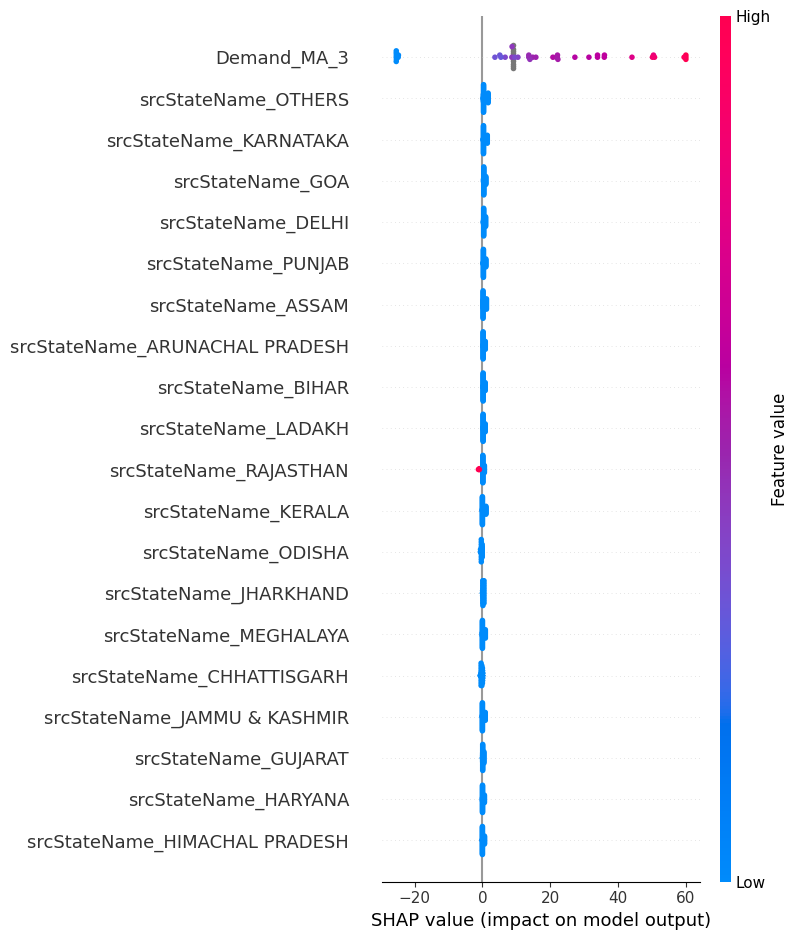

In [140]:
# -----------------------------------------------------------
# SHAP EXPLAINABILITY
# -----------------------------------------------------------

import shap

# Ensure X_train and X_test are purely numerical (float)
X_train = X_train.astype(float)
X_test = X_test.astype(float)

# Create SHAP explainer
explainer = shap.Explainer(model, X_train)

# Compute SHAP values
shap_values = explainer(X_test)

# Plot feature importance
shap.summary_plot(shap_values, X_test)

In [141]:
# -----------------------------------------------------------
# PERFORMANCE METRICS
# -----------------------------------------------------------

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(mean_squared_error(y_test, predictions))

mape = np.mean(np.abs((y_test - predictions)/y_test))*100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE: 5.779714118571414
RMSE: 10.931923256754855
MAPE: 303.32630656911726


In [142]:
# -----------------------------------------------------------
# ROLLING BACKTEST
# -----------------------------------------------------------

window = 180
errors = []

series = df['coal_consumption']

for i in range(window, len(series)):

    train = series[:i]
    test = series[i]

    forecast = train.iloc[-1]

    error = abs(test - forecast)

    errors.append(error)

print("Rolling Backtest Error:", np.mean(errors))

Rolling Backtest Error: 5.816764705882353


In [143]:
# -----------------------------------------------------------
# FINANCIAL IMPACT
# -----------------------------------------------------------

holding_cost = 50

forecast_error = abs(y_test - predictions)

financial_impact = forecast_error * holding_cost

print("Total Financial Impact:", financial_impact.sum())

Total Financial Impact: 14449.285296428536


Financial impact = Forecast Error × Holding Cost

In [144]:
financial_loss = abs(y_test - predictions) * holding_cost

In [145]:
# -----------------------------------------------------------
# BIAS DETECTION
# -----------------------------------------------------------

bias = np.mean(predictions - y_test)

if bias < 0:
    print("Under forecasting risk detected")
elif bias > 0:
    print("Over forecasting bias detected")
else:
    print("No systematic bias")

Over forecasting bias detected


In [146]:
# -----------------------------------------------------------
# QUALITY GATE
# -----------------------------------------------------------

percentile_error = np.percentile(abs(y_test - predictions),95)

threshold = 15

if percentile_error < threshold:
    print("Model passes quality gate")
else:
    print("Model fails quality gate")

Model fails quality gate


In [147]:
# -----------------------------------------------------------
# SUCCESS CRITERIA
# -----------------------------------------------------------

if mape < 10:
    print("MAPE requirement satisfied")

if rmse < 20:
    print("RMSE requirement satisfied")

RMSE requirement satisfied


In [148]:
# -----------------------------------------------------------
# CHECK HARDWARE CONFIGURATION
# -----------------------------------------------------------

import platform
import multiprocessing

print("Operating System:", platform.system())
print("CPU Cores:", multiprocessing.cpu_count())

Operating System: Linux
CPU Cores: 2


In [149]:
# -----------------------------------------------------------
# PRODUCTION SIMULATION
# -----------------------------------------------------------

import pandas as pd
import numpy as np # Import numpy for random choice
import os # Import os for file operations

production_file_path = "production_input_data.csv"

# Unconditionally create/overwrite the dummy production_input_data.csv
# This ensures the file always has the correct structure for the simulation
print(f"Creating/Overwriting '{production_file_path}' for simulation...")

# Use a small sample from X_test and y_test for simulation data structure
dummy_prod_features = X_test.head(5).copy()
dummy_prod_target = y_test.head(5).copy()

# Combine features and target for the dummy production data
dummy_prod_data = dummy_prod_features.copy()
dummy_prod_data['coal_consumption'] = dummy_prod_target

# Add the 'date' column using the original df's dates corresponding to these indices
# Ensure the index of dummy_prod_data aligns with the original df for .loc access
dummy_prod_data['date'] = df.loc[dummy_prod_data.index, 'date']

# Reorder columns to ensure 'date' is present for the drop operation later
# and 'coal_consumption' is present for evaluation
cols = ['date', 'coal_consumption'] + [col for col in dummy_prod_data.columns if col not in ['date', 'coal_consumption']]
dummy_prod_data = dummy_prod_data[cols]

dummy_prod_data.to_csv(production_file_path, index=False)
print("Dummy production input data created.")

# Load production-like dataset
production_data = pd.read_csv(production_file_path)

X_prod = production_data.drop(['date', 'coal_consumption'], axis=1) # Drop coal_consumption as it's the target

# Ensure the columns in X_prod match the columns X_train was trained on
# This is crucial if X_prod might have different columns (e.g., from different one-hot encoding)
# For a simple simulation, we can assume matching columns, but for robustness:
missing_cols = set(X_train.columns) - set(X_prod.columns)
for c in missing_cols:
    X_prod[c] = 0 # Add missing one-hot encoded columns as zero
X_prod = X_prod[X_train.columns] # Ensure order of columns is the same

# Generate predictions
production_predictions = model.predict(X_prod)

print("Production predictions generated")

Creating/Overwriting 'production_input_data.csv' for simulation...
Dummy production input data created.
Production predictions generated


In [150]:
# Evaluate performance
from sklearn.metrics import mean_absolute_error

mae_prod = mean_absolute_error(
    production_data['coal_consumption'],
    production_predictions
)

print("Production MAE:", mae_prod)

Production MAE: 4.734143635714288


In [151]:
# -----------------------------------------------------------
# GENERATE USER FRIENDLY OUTPUT
# -----------------------------------------------------------

forecast_output = pd.DataFrame({

    "Date": production_data["date"],
    "Predicted Coal Demand": production_predictions

})

forecast_output.to_csv("coal_forecast_output.csv", index=False)

print("Forecast file generated for business users")

Forecast file generated for business users


In [152]:
# -----------------------------------------------------------
# INPUT VALIDATION
# -----------------------------------------------------------

def validate_input(data):

    if data.isnull().sum().sum() > 0:
        raise ValueError("Missing values detected")

    if len(data) == 0:
        raise ValueError("Input dataset empty")

    print("Input validation passed")

In [153]:
# -----------------------------------------------------------
# ANOMALY DETECTION
# -----------------------------------------------------------

def detect_anomalies(predictions):

    threshold = predictions.mean() + 3 * predictions.std()

    anomalies = predictions[predictions > threshold]

    return anomalies

In [154]:
# -----------------------------------------------------------
# ERROR LOGGING
# -----------------------------------------------------------

import logging

logging.basicConfig(
    filename="model_errors.log",
    level=logging.ERROR
)

try:
    predictions = model.predict(X_prod)

except Exception as e:
    logging.error("Prediction failure: " + str(e))

In [155]:
# -----------------------------------------------------------
# DAILY FORECAST PIPELINE
# -----------------------------------------------------------

import pandas as pd
import os

def run_forecast_pipeline():
    # Create dummy daily_input_data.csv if it doesn't exist
    daily_file_path = "daily_input_data.csv"
    if not os.path.exists(daily_file_path):
        print(f"Creating dummy '{daily_file_path}' for daily forecast simulation...")
        # Use a small sample from production_data for daily input structure
        dummy_daily_data = production_data.head(1).copy() # Take one sample
        # In a real scenario, this would be actual new daily data
        dummy_daily_data['date'] = pd.to_datetime('2021-01-01') # Example new date

        # Ensure columns match X_train + 'date'
        # Align with X_train columns and add 'date' and 'coal_consumption' for simulation setup
        cols_for_daily_input = ['date'] + X_train.columns.tolist()
        # Create an empty DataFrame with the required columns
        temp_df = pd.DataFrame(columns=cols_for_daily_input)
        # Fill the first row with values from dummy_daily_data and a new date
        for col in dummy_daily_data.columns:
            if col in temp_df.columns:
                temp_df.loc[0, col] = dummy_daily_data.loc[dummy_daily_data.index[0], col]

        # Set default values for any new one-hot encoded state columns that might not be in the single sample
        for col in X_train.columns:
            if col not in temp_df.columns:
                temp_df[col] = 0.0 # Default to 0 for missing one-hot encoded states

        temp_df = temp_df[cols_for_daily_input] # Ensure column order
        temp_df.to_csv(daily_file_path, index=False)
        print("Dummy daily input data created.")

    data = pd.read_csv(daily_file_path)

    X = data.drop(['date'], axis=1)

    # Ensure the columns in X match the columns X_train was trained on
    # Add missing columns with 0 and reorder
    missing_cols = set(X_train.columns) - set(X.columns)
    for c in missing_cols:
        X[c] = 0 # Add missing one-hot encoded columns as zero
    X = X[X_train.columns] # Ensure order of columns is the same

    predictions = model.predict(X)

    output = pd.DataFrame({
        "date": data['date'],
        "forecast_coal_demand": predictions
    })

    output.to_csv("daily_forecast_output.csv", index=False)

    print("Daily forecast generated")

run_forecast_pipeline()

Daily forecast generated


In [156]:
!pip install fastapi uvicorn pyngrok nest_asyncio

In [157]:
from pyngrok import ngrok

ngrok.set_auth_token("3ATaBUa4ZHz6QtP4vSgRDEUYSFZ_6r1q8o5SNSvu8Antrr9EP")

In [158]:
import nest_asyncio
import uvicorn
import threading
import subprocess # Import subprocess to run shell commands

nest_asyncio.apply()

def run_uvicorn_in_thread():
    # Use subprocess to run uvicorn as a shell command
    # This ensures 'api:app' is loaded correctly from the api.py file
    command = ["uvicorn", "api:app", "--host", "0.0.0.0", "--port", "8000"]
    process = subprocess.Popen(command, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
    # You might want to add more robust error handling or logging for the subprocess output
    # For now, just let it run in the background

# Start Uvicorn in a separate thread
thr = threading.Thread(target=run_uvicorn_in_thread)
thr.start()

print("Uvicorn server started in a background thread via subprocess. It might take a moment to become accessible.")
print("To interact with the API, you may need to set up ngrok or similar tunneling service.")

Uvicorn server started in a background thread via subprocess. It might take a moment to become accessible.
To interact with the API, you may need to set up ngrok or similar tunneling service.


In [159]:
from fastapi import FastAPI

app = FastAPI()

@app.get("/")
def home():
    return {"message": "Coal Forecast API is running"}

@app.get("/health")
def health():
    return {"status": "healthy"}

In [160]:
import nest_asyncio
import uvicorn
import threading
import subprocess

nest_asyncio.apply()

def run_uvicorn_in_thread_from_api_py():
    # Run uvicorn as a shell command to load the app from api.py
    command = ["uvicorn", "api:app", "--host", "0.0.0.0", "--port", "8000"]
    # Use Popen to run it non-blocking
    subprocess.Popen(command, stdout=subprocess.PIPE, stderr=subprocess.PIPE)

# Start Uvicorn in a separate thread
thr = threading.Thread(target=run_uvicorn_in_thread_from_api_py)
thr.start()

print("FastAPI server from api.py started in a background thread via subprocess.")
print("To interact, use an ngrok tunnel pointing to port 8000.")

FastAPI server from api.py started in a background thread via subprocess.
To interact, use an ngrok tunnel pointing to port 8000.


In [161]:
from pyngrok import ngrok

public_url = ngrok.connect(8000)

print("Public URL:", public_url)

Public URL: NgrokTunnel: "https://uncorrectable-recessively-france.ngrok-free.dev" -> "http://localhost:8000"


In [162]:
@app.get("/")
def home():
    return {"message": "Coal Demand Forecast API is running"}

In [163]:
# -----------------------------------------------------------
# DATA DRIFT DETECTION
# -----------------------------------------------------------

from scipy.stats import ks_2samp

def detect_data_drift(train_data, new_data):

    drift_results = {}

    for column in train_data.columns:

        stat, p_value = ks_2samp(train_data[column], new_data[column])

        drift_results[column] = p_value

    return drift_results

In [164]:
# -----------------------------------------------------------
# HARDWARE MONITORING
# -----------------------------------------------------------

import psutil

cpu_usage = psutil.cpu_percent()

memory_usage = psutil.virtual_memory().percent

print("CPU Usage:", cpu_usage)
print("Memory Usage:", memory_usage)

CPU Usage: 24.6
Memory Usage: 13.7


In [165]:
# -----------------------------------------------------------
# SYSTEM VERSION CHECK
# -----------------------------------------------------------

import sys
import sklearn
import pandas

print("Python version:", sys.version)
print("Scikit-learn:", sklearn.__version__)
print("Pandas:", pandas.__version__)

Python version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Scikit-learn: 1.6.1
Pandas: 2.2.2


In [166]:
# -----------------------------------------------------------
# MODEL PERFORMANCE MONITORING
# -----------------------------------------------------------

from sklearn.metrics import mean_absolute_error

def monitor_model(actual, predicted):

    mae = mean_absolute_error(actual, predicted)

    print("Current MAE:", mae)

    return mae

In [167]:
# -----------------------------------------------------------
# MODEL RETRAINING
# -----------------------------------------------------------

from sklearn.ensemble import RandomForestRegressor

def retrain_model(X, y):

    model = RandomForestRegressor(n_estimators=200)

    model.fit(X, y)

    return model

In [168]:
import joblib

joblib.dump(model, "updated_forecast_model.pkl")

['updated_forecast_model.pkl']

Production Data
      │
      │
Data Drift Detection
      │
      │
Prediction Monitoring
      │
      │
Performance Metrics
      │
      │
Alert System
      │
      │
Model Retraining Pipeline

In [169]:
# Install MLflow if not already installed
!pip install mlflow

import mlflow

mlflow.start_run()

mlflow.log_metric("MAE", mae)
mlflow.log_metric("RMSE", rmse)

mlflow.sklearn.log_model(model,"model")

mlflow.end_run()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 814.0/814.0 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 9.0 MB/s eta 0:00:00


2026/03/04 13:33:19 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/04 13:33:19 INFO mlflow.store.db.utils: Updating database tables
2026/03/04 13:33:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/04 13:33:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [170]:
metadata = {
 "dataset_version":"v1.0",
 "rows":len(df),
 "features":list(df.columns)
}

In [171]:
# Generate requirements.txt file
!pip freeze > requirements.txt

print("requirements.txt created successfully.")

requirements.txt created successfully.


In [172]:
# Display the content of requirements.txt
with open('requirements.txt', 'r') as f:
    content = f.read()
print(content)

absl-py==1.4.0
accelerate==1.12.0
access==1.1.10.post3
affine==2.4.0
aiofiles==24.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.13.3
aiohttp-retry==2.9.1
aiosignal==1.4.0
aiosqlite==0.22.1
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.2
alembic==1.18.4
altair==5.5.0
amqp==5.3.1
annotated-doc==0.0.4
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.12.1
anywidget==0.9.21
appdirs==1.4.4
apsw==3.51.2.0
apswutils==0.1.2
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.8.3
arrow==1.4.0
arviz==0.22.0
astropy==7.2.0
astropy-iers-data==0.2026.2.23.0.48.33
astunparse==1.6.3
asyncssh==2.22.0
atpublic==5.1
attrs==25.4.0
audioread==3.1.0
Authlib==1.6.8
autograd==1.8.0
babel==2.18.0
backcall==0.2.0
beartype==0.22.9
beautifulsoup4==4.13.5
betterproto==2.0.0b6
bigframes==2.36.0
bigquery-magics==0.10.3
billiard==4.2.4
bleach==6.3.0
blinker==1.9.0
blis==1.3.3
blobfile==3.2.0
blosc2==4.0.0
bokeh==3.8.2
Bottleneck==1.4.2
bqplot==0.12.45
branca==0.8.2
brotli==1.